In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9d0f6e60819f9a5a.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9ccf708985967f09.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9ccbc2c5d1aaf078.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9bdcc23296db1516.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9cb97f87870407f0.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9bf9cca507923334.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9c077ad23a231abb.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9d6a6499354e3197.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9c3f1c10ba54ed56.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9d6acb154f9932c8.jpg
/kaggle/in

In [14]:
import cv2
import numpy as np

kernel_ret = cv2.getStructuringElement(cv2.MORPH_RECT, (40,13))

imagem_path = "/kaggle/input/plant-disease-recognition-dataset/Train/Train/Powdery/c39a78d9a060f63b.jpg"
imagem = cv2.imread(imagem_path, cv2.IMREAD_GRAYSCALE)

black_hat = cv2.morphologyEx(imagem, cv2.MORPH_BLACKHAT, kernel_ret)

sobel_x = cv2.Sobel(black_hat, ddepth = cv2.CV_32F, dx = 1, dy = 0, ksize = 1)
sobel_x = np.absolute(sobel_x)
sobel_x = sobel_x.astype('uint8')
cv2_imshow(sobel_x)

#sobel_x = cv2.Sobel(black_hat, ddepth = cv2.CV_32F, dx = 1, dy = 0, ksize = 1)
#sobel_x = np.absolute(sobel_x)
#sobel_x = sobel_x.astype('uint8')

fechamento = cv2.morphologyEx(imagem, cv2.MORPH_CLOSE, kernel_ret)
valor, mascara = cv2.threshold(fechamento, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

plt.figure(figsize=(6,6))
plt.imshow(sobel_x, cmap='gray')
plt.axis('off')
plt.show()

NameError: name 'cv2_imshow' is not defined

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim
from tensorflow.keras.callbacks import ReduceLROnPlateau
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

data_dir = "/kaggle/input/plant-disease-recognition-dataset"
train_dir = f"{data_dir}/Train/Train"
val_dir = f"{data_dir}/Validation/Validation"
test_dir = f"{data_dir}/Test/Test"

Found 1322 files belonging to 3 classes.


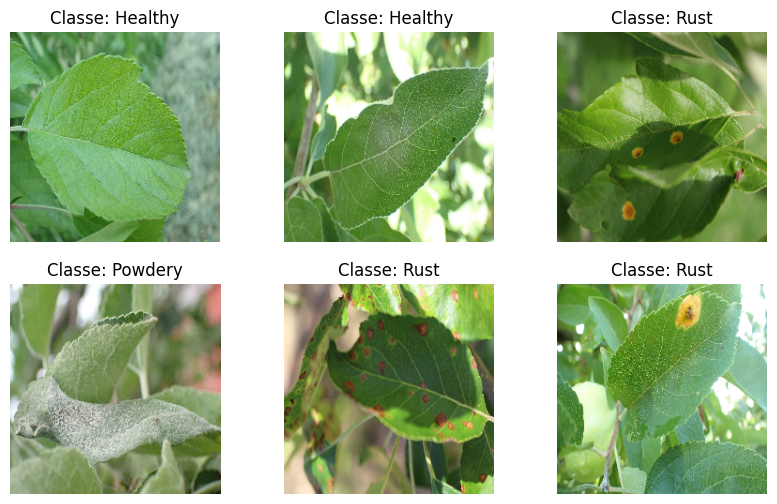

In [3]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=6
)

images, labels = next(iter(train_dataset))

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(f"Classe: {train_dataset.class_names[labels[i]]}")
    plt.axis("off")
plt.show()

Found 150 files belonging to 3 classes.


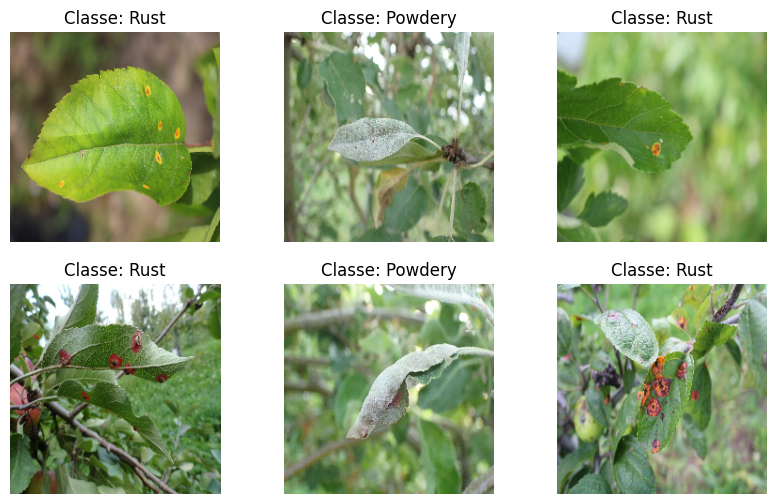

In [4]:
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=6
)

images, labels = next(iter(test_dataset))

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(f"Classe: {test_dataset.class_names[labels[i]]}")
    plt.axis("off")
plt.show()

Found 60 files belonging to 3 classes.


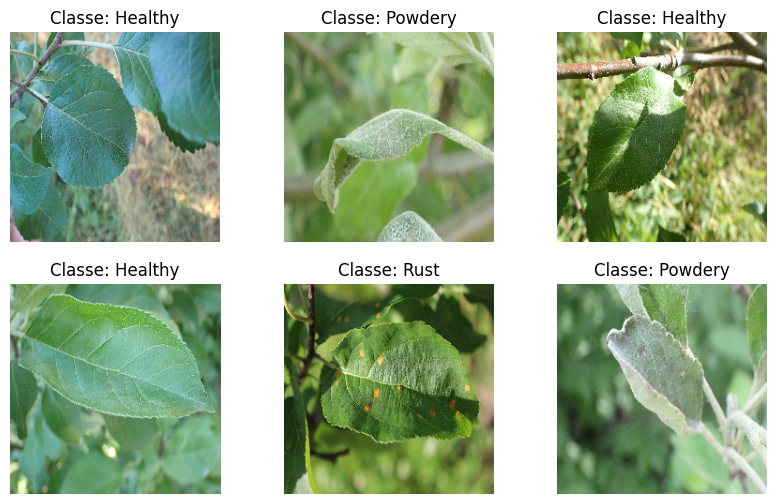

In [5]:
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(224, 224),
    batch_size=6
)

images, labels = next(iter(val_dataset))

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(f"Classe: {val_dataset.class_names[labels[i]]}")
    plt.axis("off")
plt.show()

In [24]:
print(images[0].shape)

(224, 224, 3)


In [25]:
print("Tamanho dataset train:", len(train_dataset), '\n',
      "Tamanho dataset test:", len(test_dataset), '\n', 
      "Tamanho dataset validacao:", len(val_dataset), '\n')

Tamanho dataset train: 221 
 Tamanho dataset test: 25 
 Tamanho dataset validacao: 10 



In [6]:
def plotar_graficos(history):
    fig, ax = plt.subplots(1,2, figsize=(14,5))
    ax[0].plot(history.history['loss'], color='#111487', linewidth=3, label="Perda de treinamento")
    ax[0].plot(history.history['val_loss'], color='#EFA316', linewidth=3, label="Perda da validação")
    ax[0].legend(loc='best', shadow=True)
    
    ax[1].plot(history.history['accuracy'], color='#111487', linewidth=3, label="Acurácia de treinamento")
    ax[1].plot(history.history['val_accuracy'], color='#EFA316', linewidth=3, label="Acurácia de validação")
    ax[1].legend(loc='best', shadow=True)
    
    plt.suptitle('Desempenho do treinamento', fontsize = 18)
    plt.show()

In [7]:
batch_size = 64
height = 224
width = 224

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(width, height, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
base_model = MobileNetV2(weights="imagenet", 
                         include_top=False, 
                         input_shape=(224, 224, 3))

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(3, activation="softmax")(x)

final_model = models.Model(inputs=inputs, outputs=outputs)

final_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

final_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y))
test_dataset = test_dataset.map(lambda x, y: (preprocess_input(x), y))

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',    
    factor=0.5,            
    patience=2,            
    min_lr=1e-6,          
    verbose=1              
)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05)
])

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = final_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    callbacks=[lr_scheduler]
)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 46s 162ms/step - accuracy: 0.5710 - loss: 0.9415 - val_accuracy: 0.9267 - val_loss: 0.2569 - learning_rate: 1.0000e-04
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 114ms/step - accuracy: 0.9197 - loss: 0.2894 - val_accuracy: 0.9667 - val_loss: 0.1715 - learning_rate: 1.0000e-04
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 111ms/step - accuracy: 0.9419 - loss: 0.1812 - val_accuracy: 0.9667 - val_loss: 0.1555 - learning_rate: 1.0000e-04
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 114ms/step - accuracy: 0.9562 - loss: 0.1461 - val_accuracy: 0.9667 - val_loss: 0.1485 - learning_rate: 1.0000e-04
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 42s 117ms/step - accuracy: 0.9695 - loss: 0.1182 - val_accuracy: 0.9600 - val_loss: 0.1393 - learning_rate: 1.0000e-04
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 28s 125ms/step - accuracy: 0.9719 - loss: 0.0827 - val_accuracy: 0.9600 - val_loss: 0.1213 - learning_rate: 1.0000e-04
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 26s 11

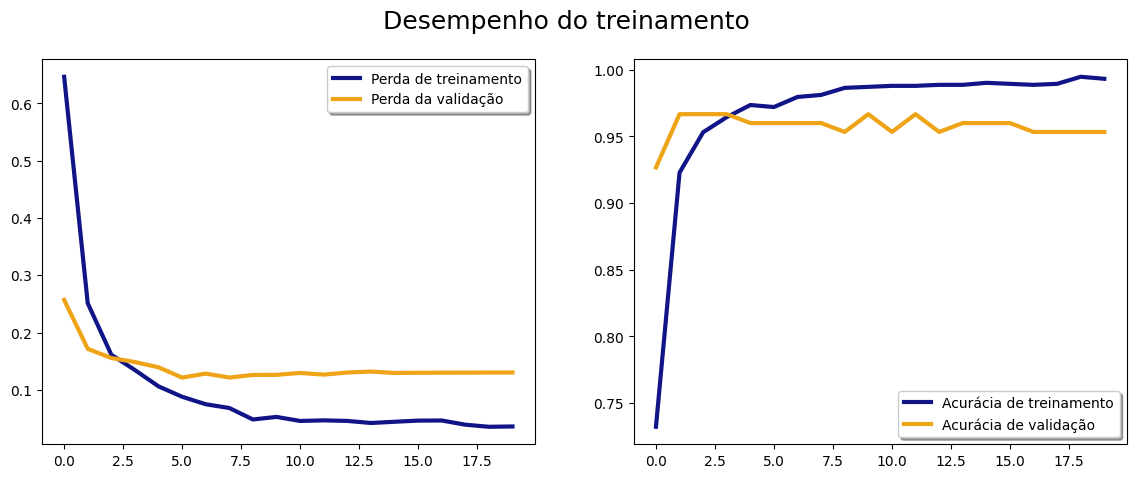

In [11]:
plotar_graficos(history)

## Usando InceptionV3

As últimas camadas são congeladas e adicionada camadas do nosso problema

In [31]:
input_shape = (224, 224, 3)

model_base_incp = tf.keras.applications.InceptionV3(input_shape = input_shape,
                                               include_top = False,
                                               weights='imagenet')

model_base_incp.trainable = False

rescale = tf.keras.layers.Rescaling((1./224))
train_dataset = train_dataset.map(lambda x, y: (rescale(x),y))
test_dataset = test_dataset.map(lambda x, y: (rescale(x),y))

last_camada = model_base_incp.get_layer('mixed7')
print(last_camada, last_camada.output.shape)


last_output = last_camada.output

x = tf.keras.layers.Flatten()(last_output)

x = tf.keras.layers.Dense(1024, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(3, activation='softmax')(x)

model_incpt = tf.keras.Model(inputs=model_base_incp.input, outputs=x)

model_incpt.compile(optimizer= tf.keras.optimizers.Adam(),
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

history = model_incpt.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
<Concatenate name=mixed7, built=True> (None, 12, 12, 768)
Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 42s 140ms/step - accuracy: 0.3879 - loss: 12.1442 - val_accuracy: 0.3733 - val_loss: 1.0644
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 31s 119ms/step - accuracy: 0.4600 - loss: 1.0299 - val_accuracy: 0.3333 - val_loss: 1.0987
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 113ms/step - accuracy: 0.3660 - loss: 1.0891 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 44s 126ms/step - accuracy: 0.3342 - loss: 1.0956 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 31s 139ms/step - accuracy: 0.3441 - loss: 1.0947 - val_accuracy: 0.3333 - val_loss: 1.0987
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 36s 118ms/step - accuracy: 0.3546 - loss: 1.0984 - val_accuracy: 0.3333 - val_loss: 1.0987
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 39s 111ms/step - accuracy: 0.3574 - loss: 1.0981 - val_accuracy:

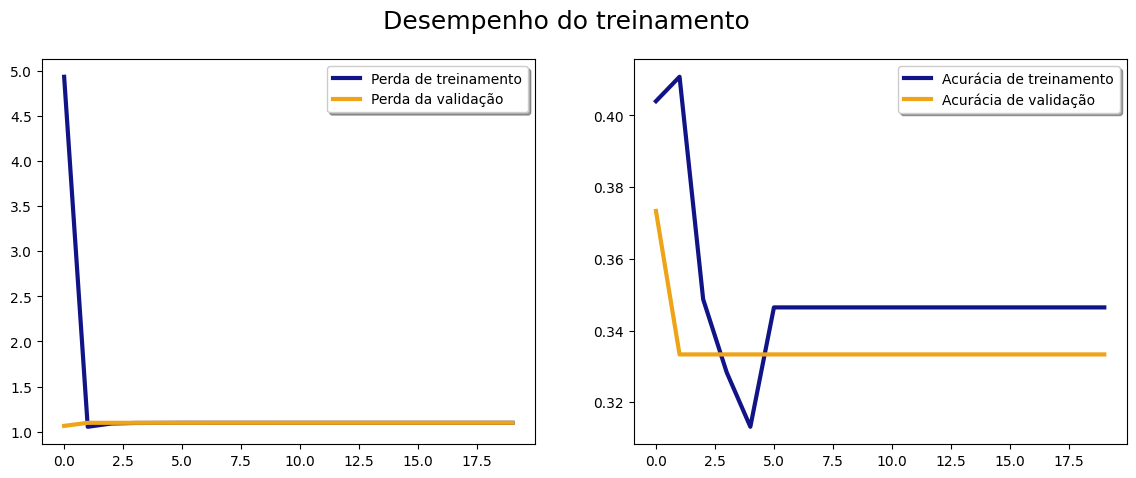

In [32]:
plotar_graficos(history)

In [39]:
class_names = val_dataset.class_names
print(f"Classes do dataset: {class_names}\n")

for images, labels in val_dataset.take(1):
    for i in range(len(labels)):
        print(f"Imagem {i}: Classe {class_names[labels[i].numpy()]}, Label Numérico: {labels[i].numpy()}")


Classes do dataset: ['Healthy', 'Powdery', 'Rust']

Imagem 0: Classe Rust, Label Numérico: 2
Imagem 1: Classe Healthy, Label Numérico: 0
Imagem 2: Classe Rust, Label Numérico: 2
Imagem 3: Classe Powdery, Label Numérico: 1
Imagem 4: Classe Rust, Label Numérico: 2
Imagem 5: Classe Powdery, Label Numérico: 1


In [32]:
for images, labels in val_dataset.take(10):
    img = images[3]  
    label = labels[3].numpy()

    img = tf.expand_dims(img, axis=0)

    predict = final_model.predict(img)

    print(f"Predição do modelo: {predict}")
    print(f"Label real: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predição do modelo: [[0.01914315 0.78338444 0.19747241]]
Label real: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predição do modelo: [[0.05937925 0.19311804 0.74750274]]
Label real: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predição do modelo: [[0.00513973 0.44923678 0.5456235 ]]
Label real: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predição do modelo: [[0.22262874 0.6253802  0.15199101]]
Label real: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predição do modelo: [[0.0293615  0.606955   0.36368346]]
Label real: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predição do modelo: [[0.01171728 0.6694824  0.3188003 ]]
Label real: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predição do modelo: [[0.02471076 0.70092785 0.2743613 ]]
Label real: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predição do modelo: [[0.02393002 0.7036097  0.27246025]]
Label real: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predição do modelo: [[0.05365493 0.54980505 0.39654002]]
Label real: 2
1/1 ━━━━━━━━━━━━━━━

In [33]:
for images, labels in val_dataset.take(10):
    img = images[0]  
    label = labels[0].numpy()

    img = tf.expand_dims(img, axis=0)

    predict = final_model.predict(img)

    print(f"Predição do modelo: {predict}")
    print(f"Label real: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predição do modelo: [[0.05350145 0.8039661  0.14253242]]
Label real: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predição do modelo: [[0.0085129  0.43658873 0.5548983 ]]
Label real: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predição do modelo: [[0.08538987 0.27320573 0.6414044 ]]
Label real: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predição do modelo: [[0.01358194 0.24190657 0.74451154]]
Label real: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predição do modelo: [[0.03366453 0.504045   0.46229047]]
Label real: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predição do modelo: [[0.01081481 0.7669015  0.22228362]]
Label real: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predição do modelo: [[0.01856147 0.45701993 0.5244186 ]]
Label real: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predição do modelo: [[0.01084372 0.70957375 0.27958247]]
Label real: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predição do modelo: [[0.00230353 0.07883438 0.9188621 ]]
Label real: 0
1/1 ━━━━━━━━━━━━━━━

In [34]:
final_model.save_weights('.weights.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(final_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
model_tflite_quantizado = converter.convert()

with open('modelo_quantizado16bits.tflite', 'wb') as f:
    f.write(model_tflite_quantizado)


Saved artifact at '/tmp/tmpw8pxymyf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_308')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133379554490880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133380143933648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133380143937872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133380143934176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133380143936992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133380143934352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133380164898128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133380164900768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133380164896720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133380164898656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1333801649